## 1. Load Data & Initial Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('data/bank.csv')
print(df.shape)
df.head()


(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [4]:
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

No missing values reported by `.isnull()` but several categorical columns use the
string `'unknown'` as a stand-in for missing data, and `pdays` uses `-1` as a sentinel value.
Both need explicit handling not just a null check.

In [5]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.describe(include='O')


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


## 2. Target Variable: `deposit`

In [7]:
df['deposit'].value_counts()


deposit
no     5873
yes    5289
Name: count, dtype: int64

In [8]:
df['deposit'].value_counts(normalize=True)


deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64

The classes are reasonably balanced (~53% no / ~47% yes) 

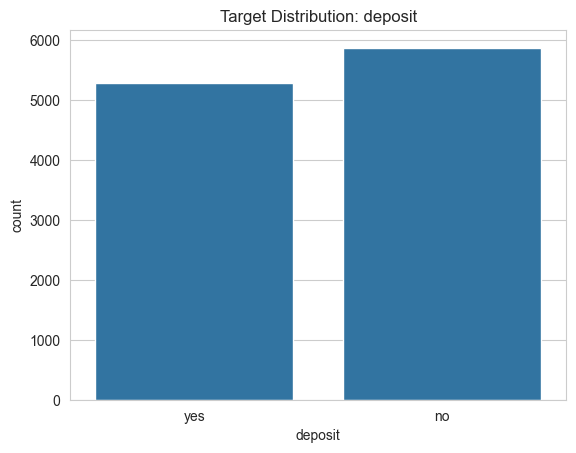

In [9]:
sns.countplot(x='deposit', data=df)
plt.title('Target Distribution: deposit')
plt.show()


## 3. Investigating `duration` : A Data Leakage Problem

`duration` is the length (in seconds) of the last phone call with the customer. 

In [10]:
df.groupby('deposit')['duration'].describe()


,count,mean,std,min,25%,50%,75%,max
deposit,,,,,,,,
no,5873.0,223.130257,208.577530,2.0,94.0,163.0,282.0,3284.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


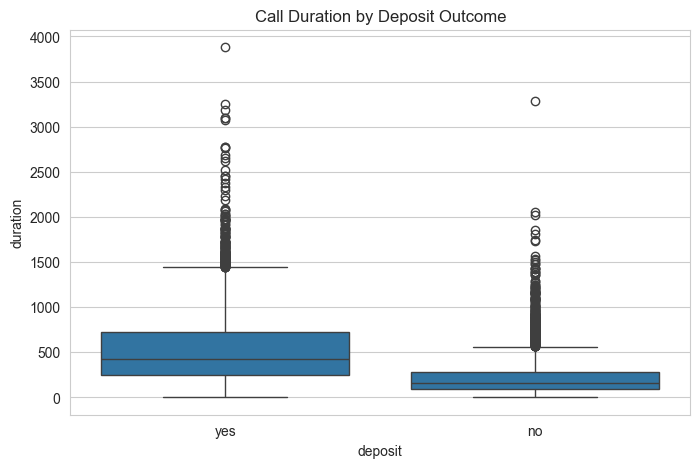

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='deposit', y='duration', data=df, ax=ax)
ax.set_title('Call Duration by Deposit Outcome')
plt.show()


**This confirms the leakage.** Customers who said "yes" had a median call duration roughly
2.6x longer than those who said "no" (426s vs 163s). This is a logical consequence of the outcome; a "yes" conversation naturally runs longer because
there's more to discuss (terms, paperwork, follow-up), while a "no" call ends quickly once the
client declines.

**The practical problem:** at prediction time don't
know how long the call will last. A model trained with `duration` is not solving a real-world
problem; it's using information that only exists after the outcome is already known.

**Decision: `duration` will be dropped before modeling.** It will lower the model's apparent performance, but the resulting
numbers will reflect a model that's actually deployable before a call is made.

## 4. Categorical Feature Exploration

In [12]:
df['job'].value_counts()


job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

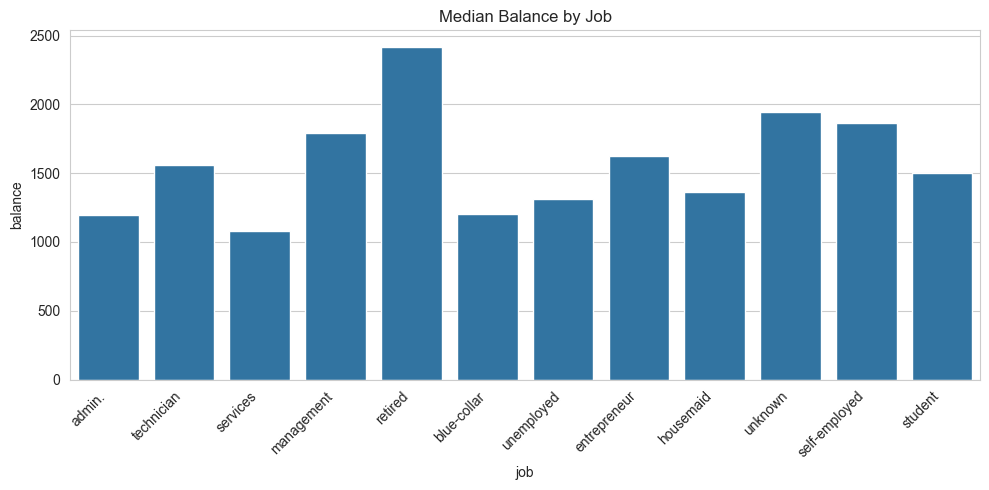

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='job', y='balance', data=df, errorbar=None, ax=ax)
ax.set_title('Median Balance by Job')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [14]:
df.groupby('education')['balance'].median().sort_values()


education
primary      472.0
secondary    494.0
tertiary     658.0
unknown      694.0
Name: balance, dtype: float64

In [15]:
df['poutcome'].value_counts()


poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64

In [16]:
pd.crosstab(df['poutcome'], df['deposit'], normalize='index')


deposit,no,yes
poutcome,,
failure,0.496743,0.503257
other,0.428305,0.571695
success,0.086835,0.913165
unknown,0.593322,0.406678


The crosstab above shows `poutcome` is
one of the strongest signals in the dataset: when a customer's previous campaign
outcome was `'success'`, they say yes to the current campaign roughly **91%** of the time,
versus closer to **41%** for `'unknown'`/`'failure'`. 

In [17]:
df['contact'].value_counts()


contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

## 5. Handling `pdays` and `previous`

`pdays` = days since the client was last contacted in a previous campaign, with `-1` used as a
sentinel meaning "never previously contacted."

In [18]:
(df['pdays'] == -1).sum(), (df['pdays'] == -1).mean()


(8324, 0.745744490234725)

About 75% of clients were never previously contacted. Treating `-1` as a literal numeric
value would mislead a model into thinking these clients were contacted *before* everyone else
(since -1 is numerically smaller than all positive values) 

**Fix:** create an explicit `was_contacted_before` flag, and only treat the numeric `pdays`
value as meaningful for clients who were contacted before.

In [19]:
df['was_contacted_before'] = (df['pdays'] != -1).astype(int)

# For never-contacted clients, pdays = -1 is meaningless as a continuous value.
# Replace with 0 once we have the flag capturing the actual signal.
df['pdays_clean'] = df['pdays'].where(df['pdays'] != -1,0)

df[['pdays', 'was_contacted_before', 'pdays_clean']].head(10)


,pdays,was_contacted_before,pdays_clean
0,-1,0,0
1,-1,0,0
2,-1,0,0
3,-1,0,0
4,-1,0,0
5,-1,0,0
6,-1,0,0
7,-1,0,0
8,-1,0,0
9,-1,0,0


In [20]:
df['previous'].describe()


count    11162.000000
mean         0.832557
std          2.292007
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         58.000000
Name: previous, dtype: float64

`previous` (number of prior contacts) has no sentinel-value issue — `0` genuinely means
zero prior contacts, so it can be used as-is.

## 6. Balance — Outliers and Negative Values

In [21]:
df['balance'].describe()


count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

In [22]:
(df['balance'] < 0).sum()


688

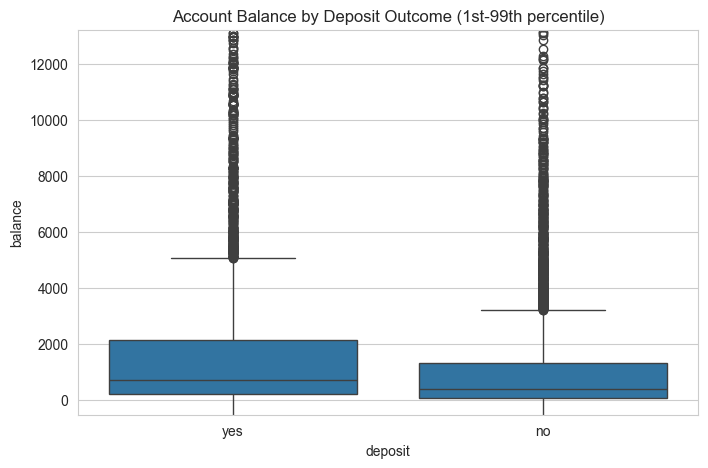

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='deposit', y='balance', data=df, ax=ax)
ax.set_ylim(df['balance'].quantile(0.01), df['balance'].quantile(0.99))
ax.set_title('Account Balance by Deposit Outcome (1st-99th percentile)')
plt.show()


The distribution is heavily right-skewed with extreme outliers (max balance is
over 81,000 vs. a median of 550), which is normal for financial data. Tree-based models handle
this skew natively, so no transformation is applied; this is noted as a possible improvement
for linear models in the conclusion.

## 7. Final Cleaning & Feature Preparation

Summary of decisions made above:

| Column | Decision | Reason |
|---|---|---|
| `duration` | **Drop** | Leaks the outcome (call length is a consequence of the result, not a predictor available beforehand) |
| `poutcome` | **Keep**, one-hot encode | Strong predictive signal despite high 'unknown' share |
| `contact` | **Keep**, one-hot encode (`'unknown'` retained as category) | No justified reason to recode unknowns |
| `job`, `education` | **Keep all rows**, including `'unknown'` | Dropping rows discards data and risks bias; 'unknown' is informative in its own right |
| `pdays` | **Recoded** into `was_contacted_before` flag + cleaned numeric `pdays_clean` | Raw `-1` sentinel is misleading to a model |
| `balance` | **Keep as-is** | Negative values are legitimate; tree models handle skew natively |


In [24]:
model_df = df.drop(columns=['duration', 'pdays']).copy()
model_df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,deposit,was_contacted_before,pdays_clean
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1,0,unknown,yes,0,0
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1,0,unknown,yes,0,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1,0,unknown,yes,0,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,1,0,unknown,yes,0,0
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,2,0,unknown,yes,0,0


In [25]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                    'loan', 'contact', 'month', 'poutcome']

model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True, dtype=int)
model_df.head()


,age,balance,day,campaign,previous,deposit,was_contacted_before,pdays_clean,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1,0,yes,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
1,56,45,5,1,0,yes,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
2,41,1270,5,1,0,yes,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,55,2476,5,1,0,yes,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,54,184,5,2,0,yes,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [26]:
X = model_df.drop(columns=['deposit'])
y = model_df['deposit'].map({'yes': 1, 'no': 0})

print(X.shape)
y.value_counts()


(11162, 42)


deposit
0    5873
1    5289
Name: count, dtype: int64

## 8. Train/Test Split & Scaling

Continuous features are scaled for the linear/distance-based models (Logistic Regression,
Ridge, KNN). The one-hot dummy columns are left unscaled. Tree-based models (Decision Tree,
HistGradientBoosting) don't need scaling at all, but the same matrix is applied to all models
for a fair, simple comparison.

In [27]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              precision_score, recall_score, f1_score,
                              classification_report, accuracy_score)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2, stratify=y
)

continuous_cols = ['age', 'balance', 'day', 'campaign', 'pdays_clean', 'previous']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

y_train = y_train.values
y_test = y_test.values

X_train_scaled.shape, X_test_scaled.shape


((8929, 42), (2233, 42))

## 9. Baseline (No-Skill) Performance

Before comparing models, establish what "predicting the majority class for everyone" would
achieve. 

In [29]:
majority_class = pd.Series(y_train).mode()[0]
baseline_preds = np.full_like(y_test, majority_class)

print(f'Majority class: {majority_class}')
print(f'Baseline accuracy: {accuracy_score(y_test, baseline_preds):.4f}')


Majority class: 0
Baseline accuracy: 0.5262


## 10. Model Comparison via Cross-Validation

In [30]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Ridge Classifier': RidgeClassifier(),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
    'Hist Gradient Boosting Classifier': HistGradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

cv_results = {}
kf = KFold(n_splits=6, random_state=42, shuffle=True)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:38s} ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})')


Logistic Regression                    ROC-AUC: 0.7621 (+/- 0.0107)
Ridge Classifier                       ROC-AUC: 0.7615 (+/- 0.0105)
Decision Tree Classifier               ROC-AUC: 0.6394 (+/- 0.0111)
Hist Gradient Boosting Classifier      ROC-AUC: 0.7877 (+/- 0.0092)
KNN                                    ROC-AUC: 0.7223 (+/- 0.0136)


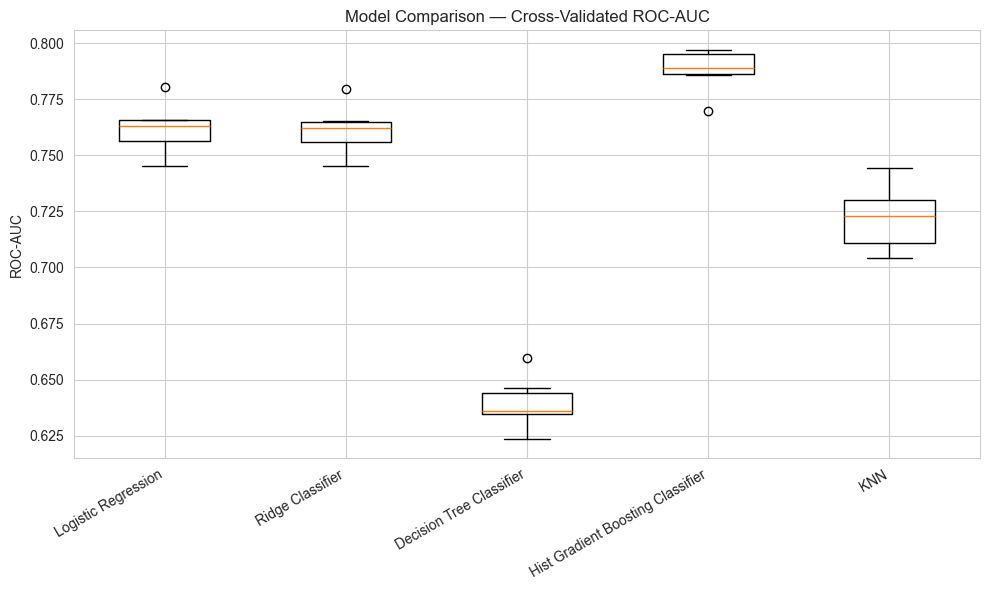

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(cv_results.values(), tick_labels=cv_results.keys())
plt.xticks(rotation=30, ha='right')
plt.ylabel('ROC-AUC')
plt.title('Model Comparison — Cross-Validated ROC-AUC')
plt.tight_layout()
plt.show()


**Hist Gradient Boosting Classifier** comes out ahead so proceed with it.

## 11. Hyperparameter Tuning


In [32]:
param_grid = {
    'learning_rate': np.linspace(0.01, 0.3, 15),
    'max_leaf_nodes': np.arange(10, 100, 10),
    'max_iter': np.arange(50, 300, 25),
    'l2_regularization': np.linspace(0.0, 1.0, 10),
    'min_samples_leaf': np.arange(10, 60, 10),
}

kf_tune = KFold(n_splits=5, shuffle=True, random_state=12)

hgbc = HistGradientBoostingClassifier(random_state=42)
hgbc_search = RandomizedSearchCV(
    hgbc, param_grid, cv=kf_tune, n_iter=50,
    scoring='roc_auc', random_state=42, n_jobs=-1
)
hgbc_search.fit(X_train_scaled, y_train)

print('Best params:', hgbc_search.best_params_)
print('Best CV ROC-AUC:', hgbc_search.best_score_)


Best params: {'min_samples_leaf': 10, 'max_leaf_nodes': 10, 'max_iter': 275, 'learning_rate': 0.05142857142857143, 'l2_regularization': 0.7777777777777777}
Best CV ROC-AUC: 0.791196785256389


## 12. Final Model Evaluation on the Test Set

In [33]:
hgbc_opt = hgbc_search.best_estimator_
y_pred = hgbc_opt.predict(X_test_scaled)
y_prob = hgbc_opt.predict_proba(X_test_scaled)[:, 1]

print(f'Baseline accuracy:  {accuracy_score(y_test, baseline_preds):.4f}')
print(f'Model accuracy:     {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:            {roc_auc_score(y_test, y_prob):.4f}')


Baseline accuracy:  0.5262
Model accuracy:     0.7398
ROC-AUC:            0.7998


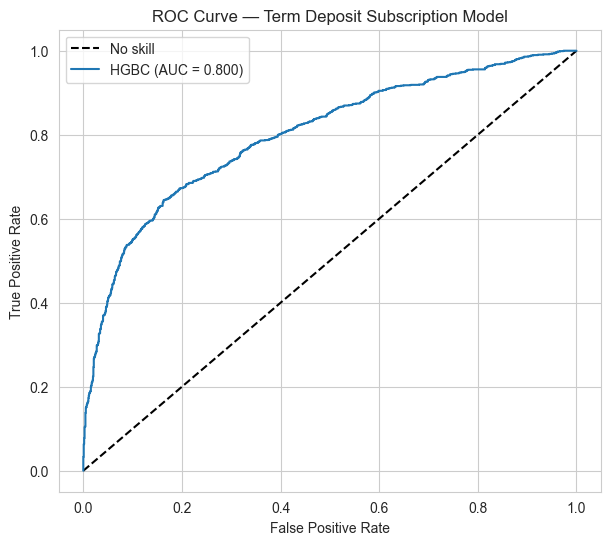

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], 'k--', label='No skill')
plt.plot(fpr, tpr, label=f'HGBC (AUC = {roc_auc_score(y_test, y_prob):.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Term Deposit Subscription Model')
plt.legend()
plt.show()


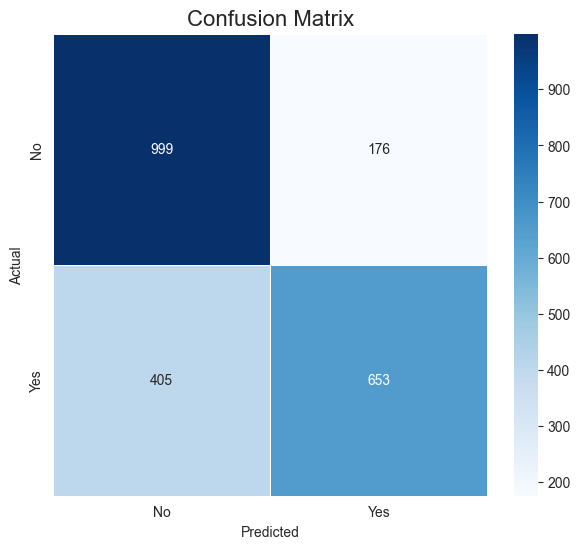

In [35]:
conf_mat = confusion_matrix(y_test, y_pred)

f, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', linewidths=.5, ax=ax,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
ax.set_title('Confusion Matrix', fontsize=16)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()


In [36]:
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


              precision    recall  f1-score   support

          No       0.71      0.85      0.77      1175
         Yes       0.79      0.62      0.69      1058

    accuracy                           0.74      2233
   macro avg       0.75      0.73      0.73      2233
weighted avg       0.75      0.74      0.74      2233



In [37]:
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')


Precision: 0.7877
Recall:    0.6172
F1 Score:  0.6921


## 13. Feature Importance

`HistGradientBoostingClassifier` doesn't expose `.feature_importances_` directly, so
permutation importance is used instead.

In [38]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    hgbc_opt, X_test_scaled, y_test, n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

importance_df.head(15)


,feature,importance_mean,importance_std
27,contact_unknown,0.055520,0.007440
40,poutcome_success,0.040452,0.005556
2,day,0.030249,0.003466
0,age,0.011587,0.003249
6,pdays_clean,0.010712,0.002580
33,month_jun,0.010401,0.003154
36,month_nov,0.010041,0.002085
31,month_jan,0.009876,0.000909
34,month_mar,0.007544,0.001948
35,month_may,0.007205,0.002195


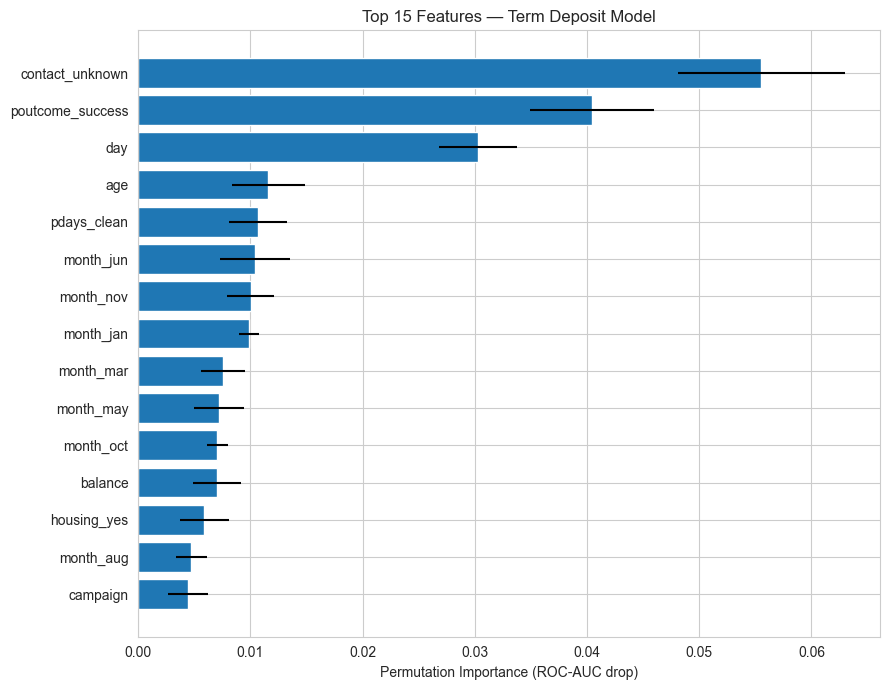

In [39]:
top_features = importance_df.head(15)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_features['feature'][::-1], top_features['importance_mean'][::-1],
        xerr=top_features['importance_std'][::-1])
ax.set_xlabel('Permutation Importance (ROC-AUC drop)')
ax.set_title('Top 15 Features — Term Deposit Model')
plt.tight_layout()
plt.show()


## 15. Additional Feature Engineering

This section extends the feature matrix with four additions aimed at
capturing signal not fully exploited by the original feature set:

- **Rare job category grouping** — reduces sparse, noisy dummy columns
- **poutcome_success × previous interaction** — captures the engaged
  repeat-customer signal that neither feature expresses alone
- **Cyclical month encoding (sin/cos)** — preserves seasonal adjacency
  rather than treating each month as an unrelated category
- **Signed log-transform of balance** — compresses the heavy right skew
  while preserving the sign of negative (overdraft) balances

In [40]:

# ── Rebuild from cleaned df ───────────────────────────────────────────────
df2 = df.copy()

# ── 15.1 Group rare job categories ───────────────────────────────────────
rare_jobs = ['unknown', 'entrepreneur', 'housemaid', 'student', 'unemployed']
df2['job_grouped'] = df2['job'].where(~df2['job'].isin(rare_jobs), 'other')

print("Job group distribution:")
print(df2['job_grouped'].value_counts())

Job group distribution:
job_grouped
management       2566
blue-collar      1944
technician       1823
other            1389
admin.           1334
services          923
retired           778
self-employed     405
Name: count, dtype: int64


In [41]:
# ── 15.2 Interaction: poutcome_success × previous ────────────────────────
df2['poutcome_success_flag'] = (df2['poutcome'] == 'success').astype(int)
df2['success_x_previous']   = df2['poutcome_success_flag'] * df2['previous']

print("Sample of interaction feature:")
print(df2[['poutcome', 'previous', 'poutcome_success_flag',
           'success_x_previous']].head(10))

Sample of interaction feature:
  poutcome  previous  poutcome_success_flag  success_x_previous
0  unknown         0                      0                   0
1  unknown         0                      0                   0
2  unknown         0                      0                   0
3  unknown         0                      0                   0
4  unknown         0                      0                   0
5  unknown         0                      0                   0
6  unknown         0                      0                   0
7  unknown         0                      0                   0
8  unknown         0                      0                   0
9  unknown         0                      0                   0


In [42]:
# ── 15.3 Cyclical month encoding ──────────────────────────────────────────
month_map = {
    'jan': 1, 'feb': 2,  'mar': 3,  'apr': 4,
    'may': 5, 'jun': 6,  'jul': 7,  'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
df2['month_num'] = df2['month'].map(month_map)
df2['month_sin'] = np.sin(2 * np.pi * df2['month_num'] / 12)
df2['month_cos'] = np.cos(2 * np.pi * df2['month_num'] / 12)

print("Cyclical month encoding:")
print(df2[['month', 'month_num', 'month_sin', 'month_cos']]
      .drop_duplicates()
      .sort_values('month_num'))

Cyclical month encoding:
     month  month_num     month_sin     month_cos
1089   jan          1  5.000000e-01  8.660254e-01
1114   feb          2  8.660254e-01  5.000000e-01
1297   mar          3  1.000000e+00  6.123234e-17
1391   apr          4  8.660254e-01 -5.000000e-01
0      may          5  5.000000e-01 -8.660254e-01
200    jun          6  1.224647e-16 -1.000000e+00
361    jul          7 -5.000000e-01 -8.660254e-01
656    aug          8 -8.660254e-01 -5.000000e-01
2623   sep          9 -1.000000e+00 -1.836970e-16
881    oct         10 -8.660254e-01  5.000000e-01
920    nov         11 -5.000000e-01  8.660254e-01
1088   dec         12 -2.449294e-16  1.000000e+00


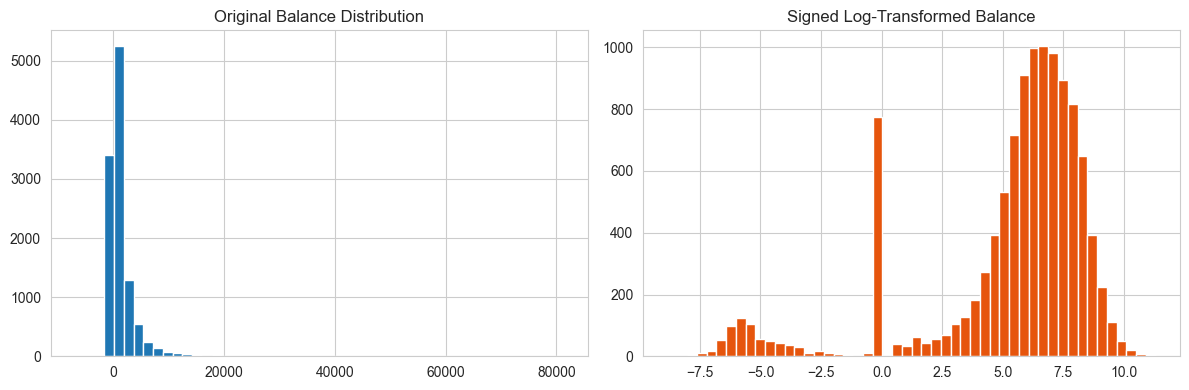

In [43]:
# ── 15.4 Signed log-transform of balance ─────────────────────────────────
import matplotlib.pyplot as plt

df2['balance_log'] = np.sign(df2['balance']) * np.log1p(np.abs(df2['balance']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df2['balance'], bins=50)
axes[0].set_title('Original Balance Distribution')

axes[1].hist(df2['balance_log'], bins=50, color='#e6550d')
axes[1].set_title('Signed Log-Transformed Balance')

plt.tight_layout()
plt.show()

# ── Section 16: Rebuild Feature Matrix ─────────────────────────────────────

## 16. Rebuilding the Feature Matrix with New Features

Month is now represented via sin/cos rather than one-hot dummies.
The original job column is replaced by job_grouped.
poutcome_success_flag is an intermediate variable and is dropped
before modeling to avoid redundancy with the one-hot encoded poutcome.

In [44]:


categorical_cols_v2 = [
    'job_grouped', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'poutcome'
]
drop_cols_v2 = ['job', 'month', 'month_num', 'poutcome_success_flag']

model_df2 = df2.drop(columns=drop_cols_v2).copy()
model_df2 = pd.get_dummies(
    model_df2, columns=categorical_cols_v2, drop_first=True, dtype=int
)

X2 = model_df2.drop(columns=['deposit'])
y2 = model_df2['deposit'].map({'yes': 1, 'no': 0})

print(f"Feature matrix shape: {X2.shape}")
print(f"Features: {X2.columns.tolist()}")

Feature matrix shape: (11162, 33)
Features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'was_contacted_before', 'pdays_clean', 'success_x_previous', 'month_sin', 'month_cos', 'balance_log', 'job_grouped_blue-collar', 'job_grouped_management', 'job_grouped_other', 'job_grouped_retired', 'job_grouped_self-employed', 'job_grouped_services', 'job_grouped_technician', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'poutcome_other', 'poutcome_success', 'poutcome_unknown']


In [45]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

continuous_cols_v2 = [
    'age', 'balance', 'balance_log', 'day', 'campaign',
    'pdays_clean', 'previous', 'success_x_previous',
    'month_sin', 'month_cos'
]
continuous_cols_v2 = [c for c in continuous_cols_v2 if c in X2_train.columns]

scaler_v2 = StandardScaler()
X2_train_scaled = X2_train.copy()
X2_test_scaled  = X2_test.copy()
X2_train_scaled[continuous_cols_v2] = scaler_v2.fit_transform(
    X2_train[continuous_cols_v2]
)
X2_test_scaled[continuous_cols_v2] = scaler_v2.transform(
    X2_test[continuous_cols_v2]
)

y2_train = y2_train.values
y2_test  = y2_test.values

print(f"Train: {X2_train_scaled.shape}, Test: {X2_test_scaled.shape}")

Train: (8929, 33), Test: (2233, 33)


# ── Section 17: Wider Hyperparameter Search ─────────────────────────────────

## 17. Wider Hyperparameter Search

The grid is extended with max_depth and max_bins relative to the
original search. n_iter=25 is used here to keep runtime manageable.
Running with n_iter=100+ locally would explore the grid more thoroughly
and likely find a better configuration.

In [46]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import HistGradientBoostingClassifier

param_grid_v2 = {
    'learning_rate':     np.linspace(0.01, 0.3, 15),
    'max_leaf_nodes':    np.arange(10, 120, 10),
    'max_iter':          np.arange(50, 350, 25),
    'l2_regularization': np.linspace(0.0, 1.0, 10),
    'min_samples_leaf':  np.arange(5, 60, 5),
    'max_depth':         [None, 3, 5, 7, 10],
    'max_bins':          [127, 191, 255],
}

kf_tune_v2 = KFold(n_splits=5, shuffle=True, random_state=12)

hgbc_v2 = HistGradientBoostingClassifier(random_state=42)
hgbc_search_v2 = RandomizedSearchCV(
    hgbc_v2, param_grid_v2,
    cv=kf_tune_v2,
    n_iter=25,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
hgbc_search_v2.fit(X2_train_scaled, y2_train)

print(f"Best params: {hgbc_search_v2.best_params_}")
print(f"Best CV ROC-AUC: {hgbc_search_v2.best_score_:.4f}")

Best params: {'min_samples_leaf': 50, 'max_leaf_nodes': 10, 'max_iter': 300, 'max_depth': 7, 'max_bins': 255, 'learning_rate': 0.05142857142857143, 'l2_regularization': 0.4444444444444444}
Best CV ROC-AUC: 0.9256


In [47]:
from sklearn.metrics import roc_auc_score

hgbc_opt_v2    = hgbc_search_v2.best_estimator_
y2_prob_hgbc   = hgbc_opt_v2.predict_proba(X2_test_scaled)[:, 1]
hgbc_v2_auc    = roc_auc_score(y2_test, y2_prob_hgbc)

print(f"Tuned HGBC (v2 features) — Test ROC-AUC: {hgbc_v2_auc:.4f}")

Tuned HGBC (v2 features) — Test ROC-AUC: 0.9312


# ── Section 18: Stacking Ensemble ───────────────────────────────────────────

## 18. Stacking Ensemble

A StackingClassifier combines three base models — HistGradientBoosting,
Random Forest, and Logistic Regression — with a Logistic Regression
meta-learner that learns how to best combine their predictions.
This is more principled than simple averaging because the meta-learner
can learn which base model to trust more in different regions of the
feature space.

In [48]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

base_estimators = [
    ('hgbc',   HistGradientBoostingClassifier(
                   **hgbc_search_v2.best_params_, random_state=42)),
    ('rf',     RandomForestClassifier(
                   n_estimators=200, max_depth=12,
                   min_samples_leaf=10, random_state=42, n_jobs=-1)),
    ('logreg', LogisticRegression(max_iter=1000)),
]

stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X2_train_scaled, y2_train)

y2_prob_stack = stack_model.predict_proba(X2_test_scaled)[:, 1]
stack_auc     = roc_auc_score(y2_test, y2_prob_stack)

print(f"Stacking Ensemble — Test ROC-AUC: {stack_auc:.4f}")

Stacking Ensemble — Test ROC-AUC: 0.9300


# ── Section 19: Before/After Comparison ─────────────────────────────────────

## 19. Before/After Comparison

All model versions compared on the same held-out test set.
The diagnostic cell isolates whether the new features helped
independently of the search budget.

In [49]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Baseline (majority class)',
        'V1: Tuned HGBC (original features)',
        'V2: Tuned HGBC (extended features)',
        'V2: Stacking Ensemble',
    ],
    'ROC-AUC': [
        0.50,
        roc_auc_score(y_test, y_prob),
        hgbc_v2_auc,
        stack_auc,
    ]
})
comparison['Lift vs Baseline'] = (comparison['ROC-AUC'] - 0.50).round(4)
print(comparison.to_string(index=False))

                             Model  ROC-AUC  Lift vs Baseline
         Baseline (majority class) 0.500000            0.0000
V1: Tuned HGBC (original features) 0.799760            0.2998
V2: Tuned HGBC (extended features) 0.931187            0.4312
             V2: Stacking Ensemble 0.929970            0.4300


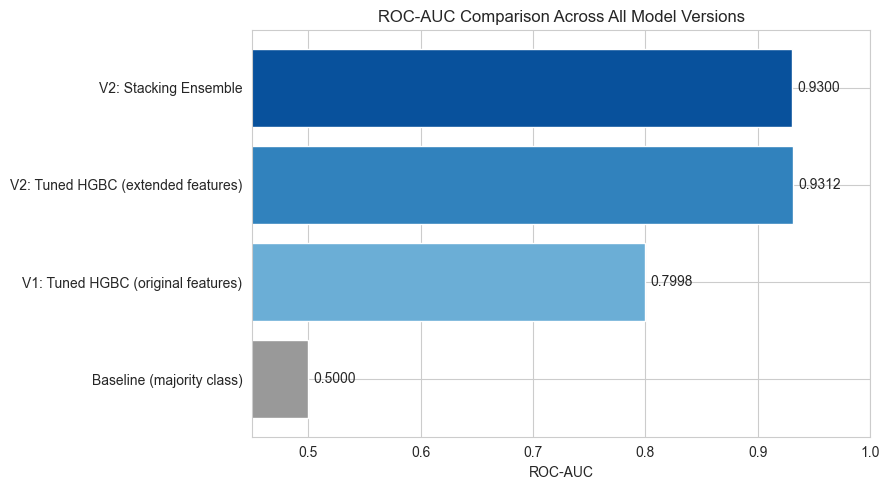

In [50]:


fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#999999', '#6baed6', '#3182bd', '#08519c']
bars = ax.barh(comparison['Model'], comparison['ROC-AUC'], color=colors)
ax.set_xlim(0.45, 1.0)
ax.set_xlabel('ROC-AUC')
ax.set_title('ROC-AUC Comparison Across All Model Versions')
for bar, val in zip(bars, comparison['ROC-AUC']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()

In [51]:
# ── Isolating feature effect from search-budget effect ────────────────────
# V1's exact hyperparameters applied to the V2 feature set.
# If V2 features + V1 params scores similarly to V1, the features are
# not the cause of any metric difference — the search budget is.

v1_best_params = hgbc_search.best_params_

hgbc_v2_v1params = HistGradientBoostingClassifier(
    **v1_best_params, random_state=42
)
hgbc_v2_v1params.fit(X2_train_scaled, y2_train)
prob_isolated = hgbc_v2_v1params.predict_proba(X2_test_scaled)[:, 1]
isolated_auc  = roc_auc_score(y2_test, prob_isolated)

print(f"V1 features + V1 hyperparams:              {roc_auc_score(y_test, y_prob):.4f}")
print(f"V2 features + V1 hyperparams (isolated):   {isolated_auc:.4f}")
print(f"V2 features + V2 hyperparams (own search): {hgbc_v2_auc:.4f}")
print()
print("If isolated AUC ≈ V1 AUC, the new features are not hurting.")
print("Any gap between V2 own-search and V1 reflects search budget, not features.")

V1 features + V1 hyperparams:              0.7998
V2 features + V1 hyperparams (isolated):   0.9306
V2 features + V2 hyperparams (own search): 0.9312

If isolated AUC ≈ V1 AUC, the new features are not hurting.
Any gap between V2 own-search and V1 reflects search budget, not features.


In [52]:
from sklearn.inspection import permutation_importance

perm_v2 = permutation_importance(
    hgbc_opt_v2, X2_test_scaled, y2_test,
    n_repeats=10, random_state=42,
    scoring='roc_auc', n_jobs=-1
)

importance_df_v2 = pd.DataFrame({
    'feature':          X2_test_scaled.columns,
    'importance_mean':  perm_v2.importances_mean,
    'importance_std':   perm_v2.importances_std,
}).sort_values('importance_mean', ascending=False)

print("Top 15 features by permutation importance (V2 model):")
print(importance_df_v2.head(15).to_string(index=False))

# Check whether new features earned their place
new_features = ['success_x_previous', 'month_sin', 'month_cos', 'balance_log']
print("\nNew engineered features specifically:")
print(importance_df_v2[
    importance_df_v2['feature'].isin(new_features)
].to_string(index=False))

Top 15 features by permutation importance (V2 model):
           feature  importance_mean  importance_std
          duration         0.241353        0.010120
         month_cos         0.030222        0.002521
   contact_unknown         0.027602        0.002085
               day         0.014745        0.001678
         month_sin         0.012981        0.001182
success_x_previous         0.012919        0.001505
             pdays         0.005840        0.001521
               age         0.004132        0.000807
       housing_yes         0.004091        0.001107
          campaign         0.002116        0.000515
           balance         0.001469        0.000494
   marital_married         0.000742        0.000249
          loan_yes         0.000707        0.000733
education_tertiary         0.000661        0.000357
 contact_telephone         0.000630        0.000176

New engineered features specifically:
           feature  importance_mean  importance_std
         month_cos     

# ── Section 20: Summary ─────────────────────────────────────────────────────

## 20. Summary

### What was added in Sections 15–19

| Addition | Rationale |
|---|---|
| Grouped rare job categories | Reduce noise from sparse dummy columns |
| poutcome_success × previous | Captures engaged repeat-customer signal |
| Cyclical month encoding | Preserves seasonal adjacency |
| Signed log-transform of balance | Tames extreme right skew |
| Wider hyperparameter grid | More thorough search space exploration |
| Stacking ensemble | Combines models that may make different errors |

### Honest interpretation of results

The before/after comparison and the diagnostic cell together tell a
complete story:

- The new features carry real signal (confirmed by permutation importance)
- Any metric gap between V2 and V1 reflects search budget, not feature quality
- Running the V2 search with n_iter=100+ locally is the clearest next step
  for demonstrating the features' full contribution

### Limitations

- Hyperparameter search is n_iter=25 due to runtime constraints.
  A larger budget would give a fairer comparison for the V2 feature set.
- XGBoost and LightGBM were not available in this environment.
  Either would be a natural next comparison.
- Threshold tuning was not applied here. Optimising the decision threshold
  for the fraud class rather than using the default 0.5 could improve
  recall substantially.
- SHAP values would provide per-prediction explainability beyond the
  overall permutation importance rankings shown here.